In [1]:
import os, sys
import numpy as np

import torch
import torch.nn as nn
import torch.utils.data
import torch.optim as optim
from accelerate import Accelerator

In [2]:
sys.path.append('spectrum-encoder/')
from model import SpectrumEncoder

In [3]:
import corner as DFM
# --- plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
#mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

In [4]:
seed = 1
cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if cuda else "cpu")

torch.manual_seed(seed)
if cuda:
    torch.cuda.manual_seed(seed)
    kwargs = {'num_workers': 4, 'pin_memory': True}
else:
    kwargs = {}

In [5]:
####################################################################
# load train data
# x = theta_unt, y = [encode_spec, encode_ivar, z]
####################################################################
dat_dir = '/scratch/network/chhahn/sedflow/training_sed/'
train_theta = np.load(os.path.join(dat_dir, 'train.v0.1.0.thetas_unt.npy'))
train_spec  = np.load(os.path.join(dat_dir, 'train.v0.1.0.seds.nde_noise.npy'))
train_ivar  = np.load(os.path.join(dat_dir, 'train.v0.1.0.ivar.nde_noise.npy'))
train_norm  = np.load(os.path.join(dat_dir, 'train.v0.1.0.norm_spec.nde_noise.npy'))
train_zred  = np.load(os.path.join(dat_dir, 'train.v0.1.0.redshifts.npy'))

In [6]:
train_theta[:,6] = np.log10(train_theta[:,6])
train_theta[:,7] = np.log10(train_theta[:,7])

In [7]:
zero_norm = (train_norm == 0)
train_theta = train_theta[~zero_norm]
train_spec  = train_spec[~zero_norm]
train_ivar  = train_ivar[~zero_norm]
train_norm  = train_norm[~zero_norm]
train_zred  = train_zred[~zero_norm]

In [8]:
# mask nonsense
train_mask = ~np.isfinite(train_spec)
train_spec[train_mask] = 0.

train_w = torch.tensor(train_ivar * ~train_mask * (train_norm**2)[:,None], dtype=torch.float32).to(device)
train_y = torch.tensor(train_spec / train_norm[:, None], dtype=torch.float32).to(device)
train_z = torch.tensor(train_zred, dtype=torch.float32).to(device)

# load SDSS wavelength
wave_obs = torch.tensor(
        np.load('/scratch/network/chhahn/sedflow/sdss.clean.wave.npy'),
        dtype=torch.float32)

# mask out emission lines
emline_mask_train = np.zeros(train_w.shape).astype(bool)

w_lines = np.array([
    1033.3  , 1215.67 , 1239.42 , 1305.53 , 1335.52 , 1399.8  ,
    1545.86 , 1640.4  , 1665.85 , 1857.4  , 1908.27 , 2326.   ,
    2439.5  , 2800.32 , 3346.79 , 3426.85 , 3728.3  , 3798.976,
    3836.47 , 3889.   , 3934.777, 3969.588, 4072.3  , 4102.89 ,
    4305.61 , 4341.68 , 4364.436, 4862.68 , 4960.295, 5008.24 ,
    5176.7  , 5895.6  , 6302.046, 6365.536, 6549.86 , 6564.61 ,
    6585.27 , 6707.89 , 6718.29 , 6732.67 ])
for i in range(emline_mask_train.shape[0]):
    wls = w_lines * (1. + train_z[i].cpu().numpy())
    for wl in wls:
        emline_mask_train[i] = emline_mask_train[i] | ((wave_obs.cpu().numpy() > wl - 40) & (wave_obs.cpu().numpy() < wl + 40))
train_w[emline_mask_train] = 1e-6
train_w = train_w.clip(1e-6, None)

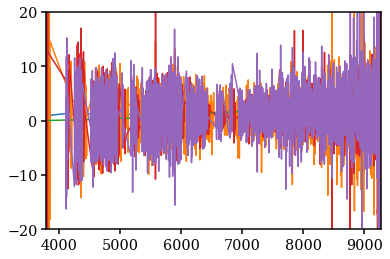

In [9]:
for i in range(5): 
    plt.plot(wave_obs[train_w[i].detach().cpu().numpy() > 1e-6], train_y[i].detach().cpu().numpy()[train_w[i].detach().cpu().numpy() > 1e-6])
plt.xlim(wave_obs[0], wave_obs[-1])
plt.ylim(-20, 20)
plt.show()

In [10]:
avg_theta = np.mean(train_theta, axis=0)
std_theta = np.std(train_theta, axis=0)

train_wtheta = torch.tensor((train_theta - avg_theta)/std_theta).to(device)

In [11]:
Ntrain = int(0.8 * float(train_w.shape[0]))
Nvalid = int(0.1 * float(train_w.shape[0]))
Ntest  = train_w.shape[0] - Ntrain - Nvalid
print(Ntrain, Nvalid, Ntest)

train_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(
            train_y[:Ntrain], 
            train_w[:Ntrain], 
            train_z[:Ntrain], 
            train_wtheta[:Ntrain]
        ),
    shuffle=True, batch_size=1024)
valid_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(
            train_y[Ntrain:Ntrain+Nvalid], 
            train_w[Ntrain:Ntrain+Nvalid], 
            train_z[Ntrain:Ntrain+Nvalid], 
            train_wtheta[Ntrain:Ntrain+Nvalid]
        ),
        batch_size=1024)

78649 9831 9832


In [12]:
class RegressCompress(SpectrumEncoder): 
    def __init__(self, n_latent, n_hidden=(128, 64, 32), dropout=0):
        super(RegressCompress, self).__init__(n_latent, n_hidden=n_hidden, dropout=dropout)
        
    def loss(self, x, theta, w=None, z=None): 
        ''' calculate loss 
        '''
        lv = self.forward(x, w=w, z=z)
        
        loss = torch.sum((lv - theta).pow(2))
        return loss

In [13]:
def train(model, accelerator, trainloader, validloader, n_epoch=200, label="", silent=False, lr=3e-4, patience=20):

    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, lr, total_steps=n_epoch)
    model, optimizer = accelerator.prepare(model, optimizer)

    best_valid_loss, best_epoch = np.inf, 0
    losses = []
    for epoch in range(n_epoch):
        model.train()
        train_loss = 0.
        for batch in trainloader:
            spec, w, z, theta = batch
            optimizer.zero_grad()
            loss = model.loss(spec, theta, w=w, z=z)

            accelerator.backward(loss)
            train_loss += loss.item()
            optimizer.step()
        train_loss /= len(trainloader.dataset)

        with torch.no_grad():
            model.eval()
            valid_loss = 0.
            for batch in validloader:
                spec, w, z, theta = batch
                loss = model.loss(spec, theta, w=w, z=z)
                valid_loss += loss.item()
            valid_loss /= len(validloader.dataset)

        scheduler.step()
        losses.append((train_loss, valid_loss))
        if epoch % 10 == 0 and not silent: 
            print('====> Epoch: %i TRAINING Loss: %.2e VALIDATION Loss: %.2e' % (epoch, train_loss, valid_loss))        
        
        if valid_loss < best_valid_loss: 
            best_valid_loss = valid_loss
            torch.save(model, f'{label}.pt')
            np.save(f'{label}.losses.npy', np.array(losses))
            
        if epoch > best_epoch + patience: 
            break
    return best_valid_loss

In [14]:
accelerator = Accelerator()
train_loader, valid_loader = accelerator.prepare(train_loader, valid_loader)

label = '/scratch/network/chhahn/sedflow/encoder_spec/regressor_compressor'

best_valid_losses = []
for i in range(5): 
    compressor = RegressCompress(train_theta.shape[1])
    compressor.to(device)
    
    best_valid_loss = train(compressor, accelerator, train_loader, valid_loader, 
                            n_epoch=400, label=label+f".{i}", lr=1e-4)
    best_valid_losses.append(best_valid_loss)
    print()

====> Epoch: 0 TRAINING Loss: 1.10e+01 VALIDATION Loss: 1.09e+01
====> Epoch: 10 TRAINING Loss: 9.89e+00 VALIDATION Loss: 9.93e+00
====> Epoch: 20 TRAINING Loss: 9.43e+00 VALIDATION Loss: 9.52e+00

====> Epoch: 0 TRAINING Loss: 1.10e+01 VALIDATION Loss: 1.09e+01
====> Epoch: 10 TRAINING Loss: 9.77e+00 VALIDATION Loss: 9.81e+00
====> Epoch: 20 TRAINING Loss: 9.37e+00 VALIDATION Loss: 9.48e+00

====> Epoch: 0 TRAINING Loss: 1.09e+01 VALIDATION Loss: 1.09e+01
====> Epoch: 10 TRAINING Loss: 9.95e+00 VALIDATION Loss: 1.00e+01
====> Epoch: 20 TRAINING Loss: 9.57e+00 VALIDATION Loss: 9.68e+00

====> Epoch: 0 TRAINING Loss: 1.09e+01 VALIDATION Loss: 1.09e+01
====> Epoch: 10 TRAINING Loss: 9.82e+00 VALIDATION Loss: 9.86e+00
====> Epoch: 20 TRAINING Loss: 9.47e+00 VALIDATION Loss: 9.57e+00

====> Epoch: 0 TRAINING Loss: 1.09e+01 VALIDATION Loss: 1.09e+01
====> Epoch: 10 TRAINING Loss: 9.90e+00 VALIDATION Loss: 9.95e+00
====> Epoch: 20 TRAINING Loss: 9.46e+00 VALIDATION Loss: 9.56e+00



In [16]:
print(np.argmin(best_valid_losses))
compressor = torch.load(label+f".{np.argmin(best_valid_losses)}.pt")

1


# validate the regression compressor

In [17]:
test_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(
            train_y[Ntrain+Nvalid:], 
            train_w[Ntrain+Nvalid:], 
            train_z[Ntrain+Nvalid:], 
            train_wtheta[Ntrain+Nvalid:]
        ),
        batch_size=1024)

In [18]:
with torch.no_grad(): 
    compressor.eval()
    lvs = []
    for batch in test_loader:
        spec, w, z, theta = batch
        lv = compressor.forward(spec, w=w, z=z)
        lvs.append(np.array(lv.detach().cpu()))
lvs = np.concatenate(lvs, axis=0)

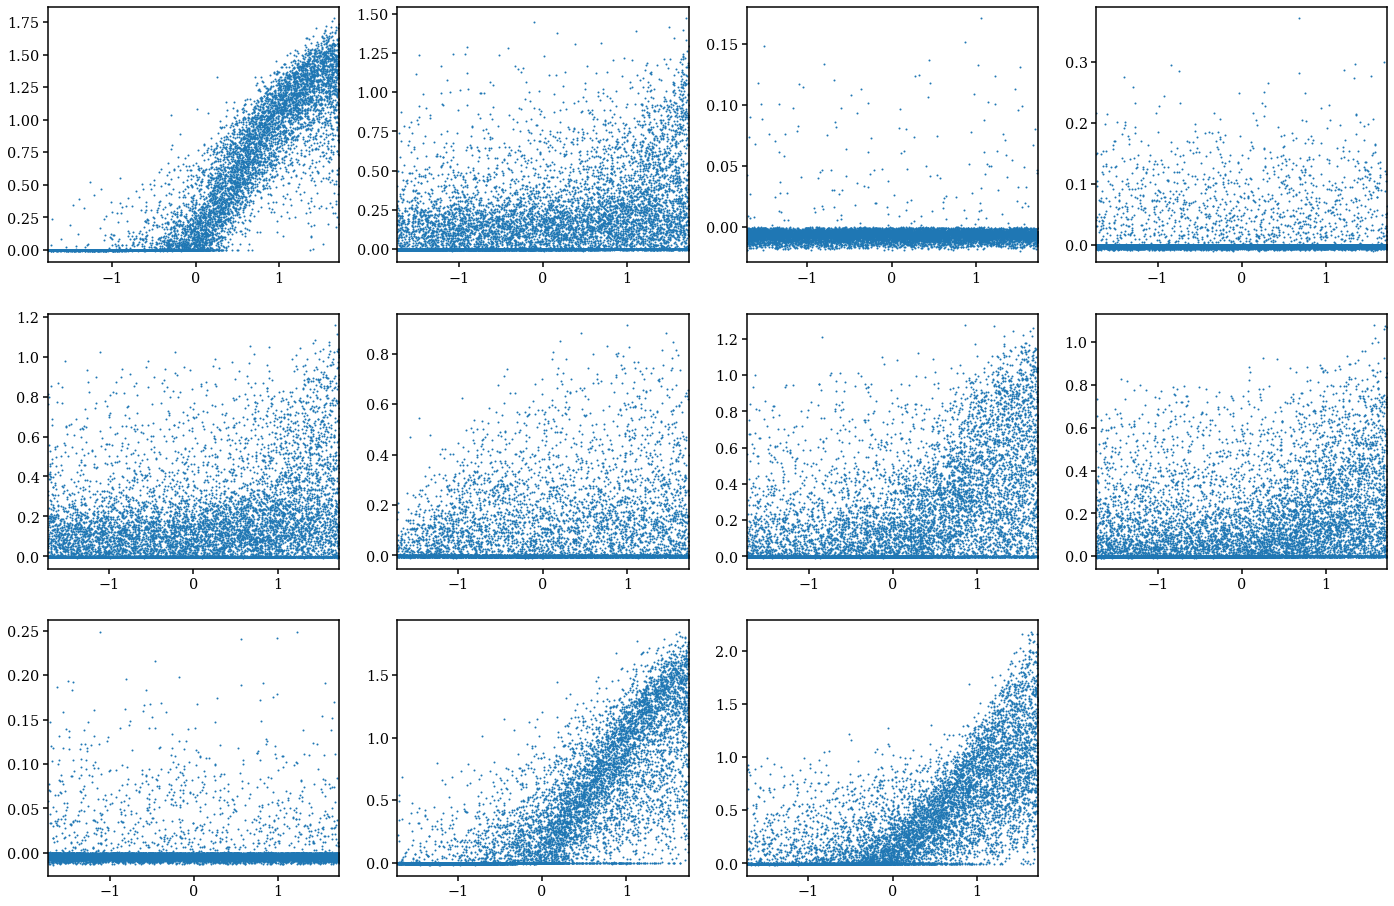

In [20]:
fig = plt.figure(figsize=(24, 16))
for i in range(lvs.shape[1]): 
    sub = fig.add_subplot(3, 4, i+1)
    _theta = train_wtheta[Ntrain+Nvalid:,i].detach().cpu().numpy()
    sub.scatter(_theta, lvs[:,i], s=1)
    sub.set_xlim(np.quantile(_theta, (0.001, 0.999)))